# NYC Taxi EDA



In [1]:
import sys, subprocess, importlib.util
print('Notebook kernel Python executable:', sys.executable)
print('Python version:', sys.version)
packages = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'pyarrow', 'fastparquet', 'missingno']
missing = [p for p in packages if importlib.util.find_spec(p) is None]
if missing:
    print('Installing missing packages into the current kernel:', missing)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install'] + missing)
    print('Installation complete. Re-run this cell if needed.')
else:
    print('All required packages are already installed in this kernel.')

for pkg in packages:
    status = importlib.util.find_spec(pkg) is not None
    print(pkg, 'available:' if status else 'missing:', status)


Notebook kernel Python executable: c:\Users\Acer\miniconda3\envs\ai\python.exe
Python version: 3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:36:00) [MSC v.1944 64 bit (AMD64)]
All required packages are already installed in this kernel.
pandas available: True
numpy available: True
matplotlib available: True
seaborn available: True
pyarrow available: True
fastparquet available: True
missingno available: True


Using parquet engine: pyarrow
Loaded dataset: (3066766, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00



Dataframe info:
<class 'pandas.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee     

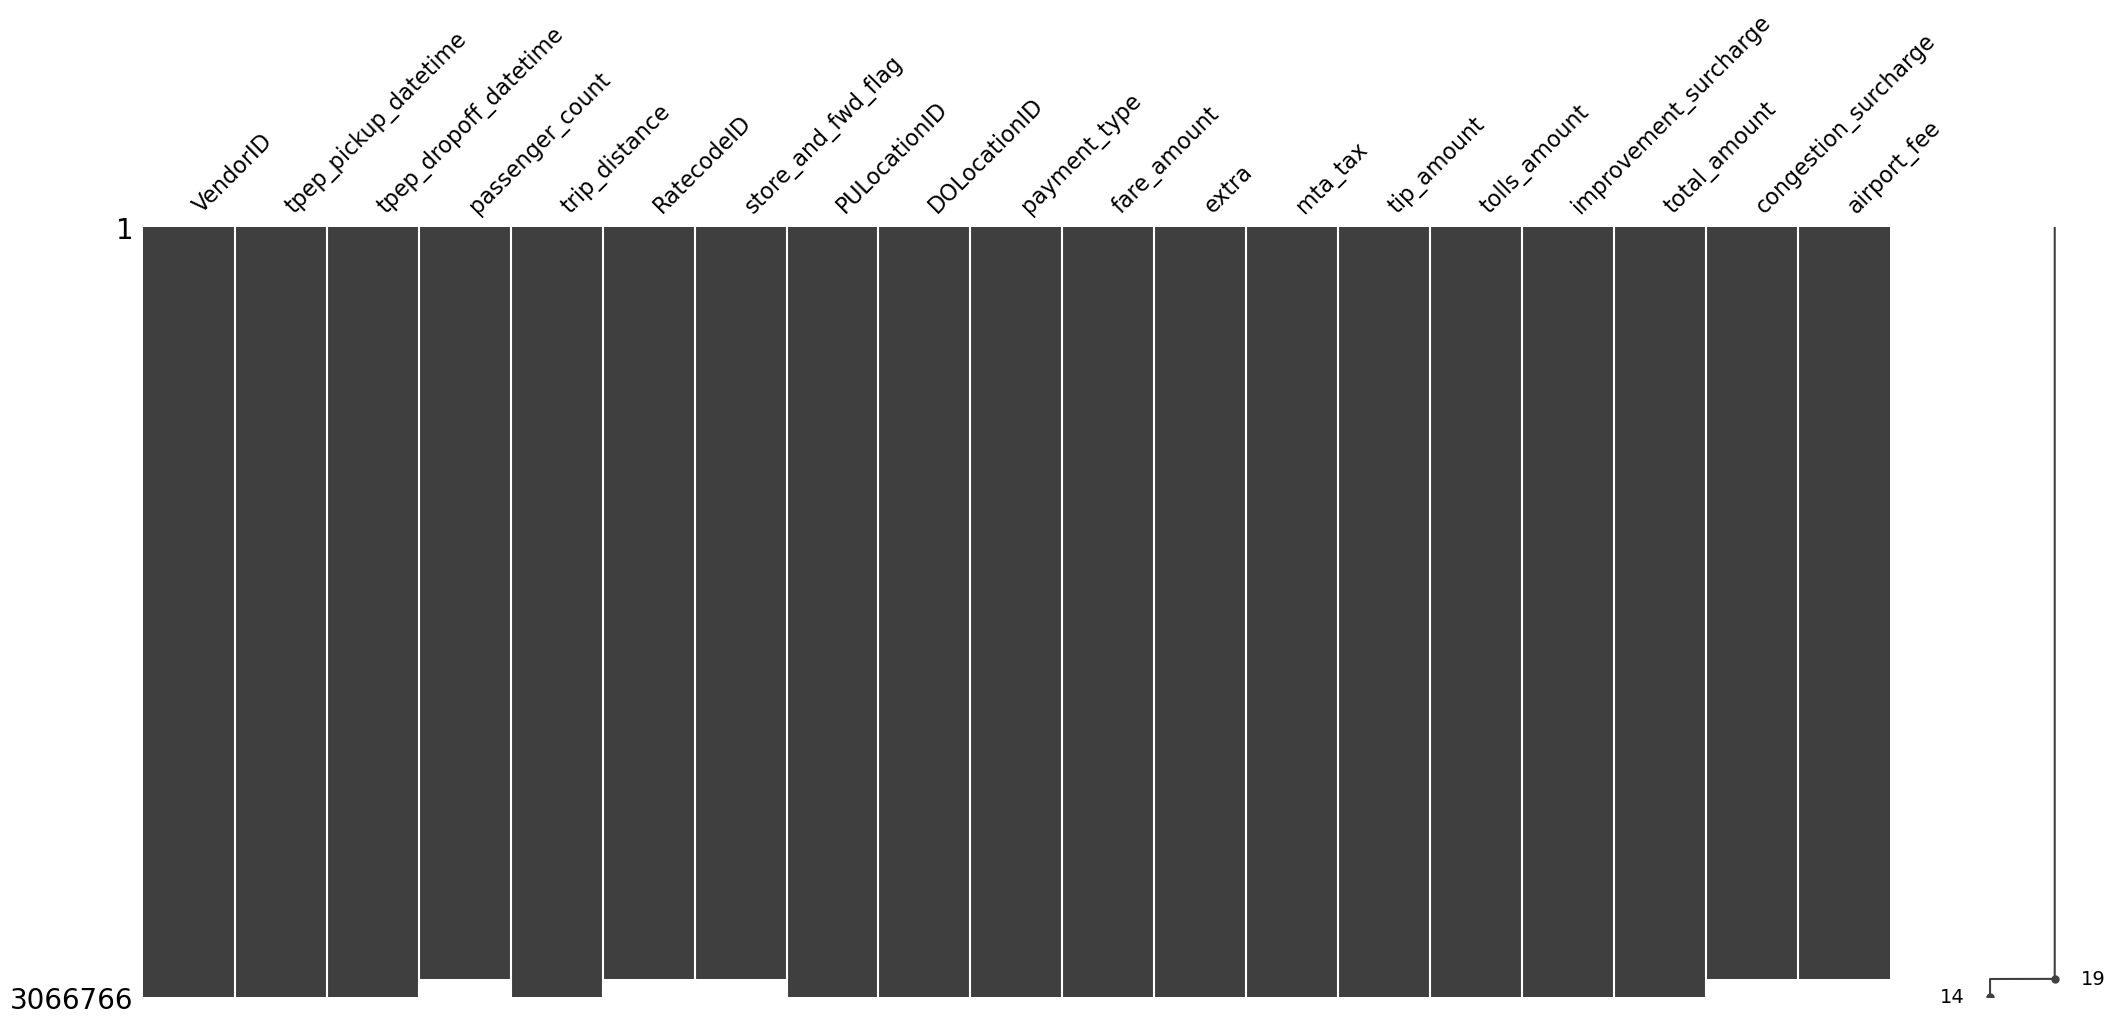

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import importlib.util

data_path = Path('yellow_tripdata_2023-01.parquet')
if not data_path.exists():
    raise FileNotFoundError(f'Dataset not found: {data_path}. Put the parquet file in this folder or update the path.')

parquet_engine = None
for engine in ('pyarrow', 'fastparquet'):
    if importlib.util.find_spec(engine) is not None:
        parquet_engine = engine
        break

if parquet_engine is None:
    raise ImportError('No parquet engine installed in the current kernel. Run the previous cell to install pyarrow or fastparquet.')

print('Using parquet engine:', parquet_engine)
df = pd.read_parquet(data_path, engine=parquet_engine)
print('Loaded dataset:', df.shape)

display(df.head())
print()
print('Dataframe info:')
df.info()
print()
print(df.describe(include='all'))

try:
    import missingno as msno
    msno.matrix(df)
except Exception as exc:
    print('missingno is not available or failed:', exc)

required_cols = ['trip_distance','fare_amount','passenger_count','tpep_pickup_datetime','tpep_dropoff_datetime']
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise KeyError(f'Missing required columns: {missing_cols}')

df = df[(df['trip_distance'] > 0) & (df['fare_amount'] > 0) & (df['passenger_count'] > 0) & (df['trip_distance'] < 100)]
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'], errors='coerce')
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'], errors='coerce')
df = df.dropna(subset=['tpep_pickup_datetime','tpep_dropoff_datetime'])
df['hour'] = df['tpep_pickup_datetime'].dt.hour
df['weekday'] = df['tpep_pickup_datetime'].dt.day_name()
df['duration_min'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
df = df[(df['duration_min'] > 0) & (df['duration_min'] < 24*60)]
df['speed_mph'] = df['trip_distance'] / (df['duration_min'] / 60)
df = df[df['speed_mph'].notna() & (df['speed_mph'] < 80)]
print(f'Clean dataset: {len(df):,} rows')


(3066766, 19)
<class 'pandas.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee        

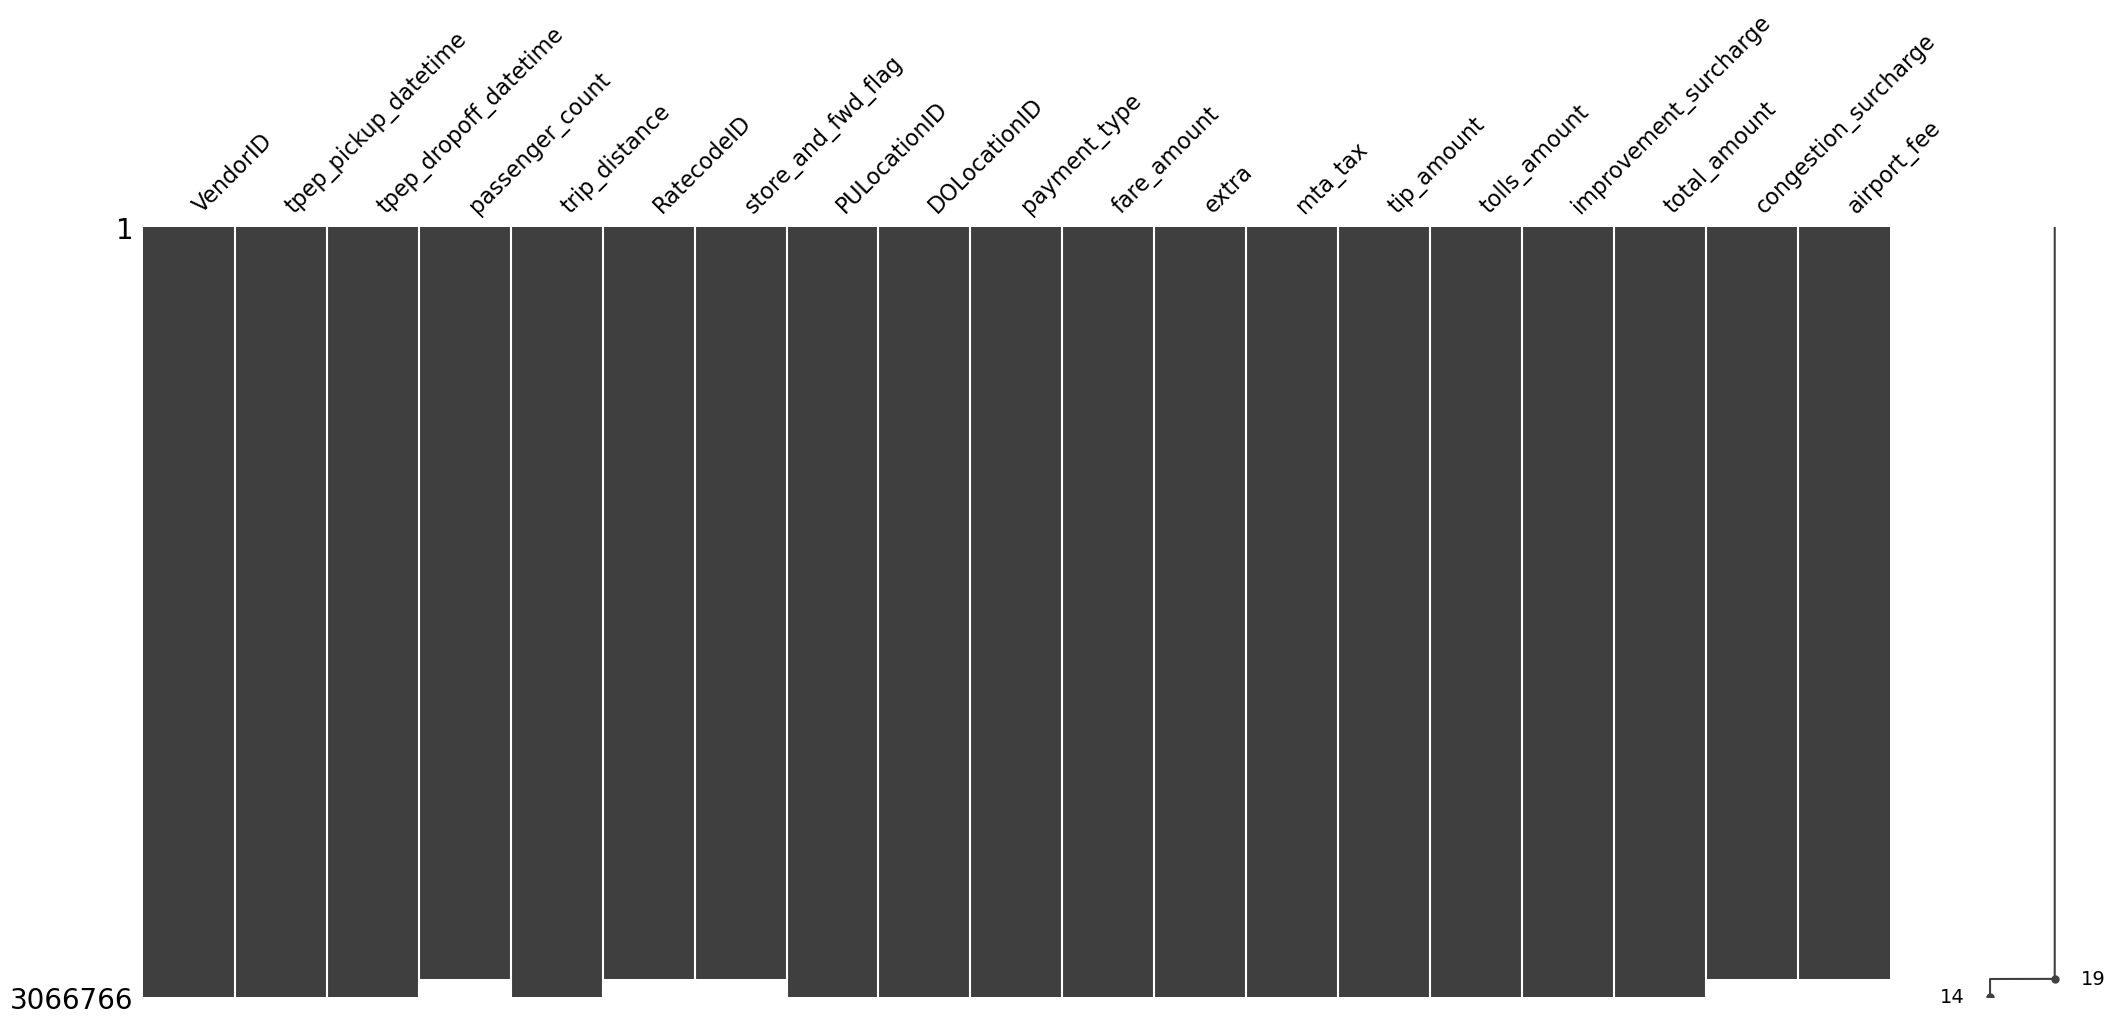

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno


# we load our dataset and print its head .
df = pd.read_parquet('yellow_tripdata_2023-01.parquet')
print(df.shape)        # expect ~3M rows, 19 cols
df.head()

# First look 
df.info()              
df.describe()          
msno.matrix(df)       

# we clean the dataset with basic rules 

# remove invalid trips
df = df[(df['trip_distance'] > 0) &
        (df['fare_amount'] > 0) &
        (df['passenger_count'] > 0) &
        (df['trip_distance'] < 100)]  

# parse datetimes
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['hour']    = df['tpep_pickup_datetime'].dt.hour
df['weekday'] = df['tpep_pickup_datetime'].dt.day_name()
df['duration_min'] = (
    (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime'])
    .dt.total_seconds() / 60
)

# creating the speed column
df['speed_mph'] = df['trip_distance'] / (df['duration_min'] / 60)
df = df[df['speed_mph'] < 80]  

print(f"Clean dataset: {len(df):,} rows")    



In [6]:
#Question 1 - When do people take taxis? Does demand peak at rush hour or late night?
hourly = df.groupby('hour').size().reset_index(name='trips')    

#Question 2 - Does trip distance correlate with tip percentage? Do long rides tip better?
df['tip_percentage'] = (df['tip_amount'] / df['fare_amount'] * 100).clip(upper=100) #calculate tip percentage and cap at 100% 
tip_by_distance = df.groupby(
    pd.cut(df['trip_distance'], bins=[0, 1, 5, 10, 20, 50, 100])
)['tip_percentage'].mean()

#Question 3 - Which payment method is most common and does it affect tip amount? (we categorize payment types as : 1= credit card, 2 = cash, 3 = no charge, 4 = other)
payment_map = {1: 'Credit Card', 2: 'Cash', 3: 'No Charge', 4: 'Other'}
df['payment'] = df['payment_type'].map(payment_map)
payment_tips = df.groupby('payment')['tip_percentage'].mean()

#Question 4 - Are there suspicious fare patterns? (Airport flat rates vs meter rides)
jfk_fares = df[df['fare_amount'].between(69, 71)] # JFK flat fare is $70, we allow a small range to account for taxes 
print(f"JFK-like fares: {len(jfk_fares):,} trips ({len(jfk_fares)/len(df)*100:.1f}%)")
jfk_fares['trip_distance'].describe()

#Question 5 - What's the average speed by hour? Does congestion show in the data?
speed_by_hour = df.groupby('hour')['speed_mph'].median()






JFK-like fares: 110,978 trips (3.8%)


FileNotFoundError: [Errno 2] No such file or directory: 'img/chart1_hourly_demand.png'

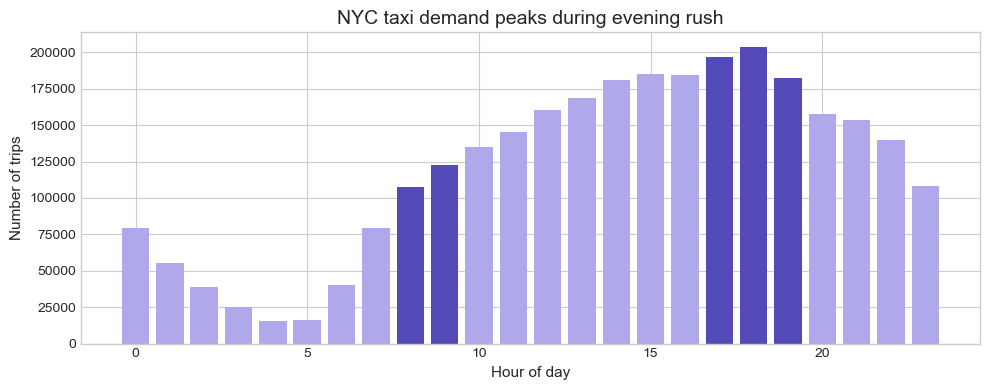

In [ ]:
from pathlib import Path

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
TITLE_SIZE, LABEL_SIZE = 14, 11

# Ensure output folder exists
output_dir = Path('img')
output_dir.mkdir(parents=True, exist_ok=True)

# Chart 1: Hourly demand (bar) 
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hourly['hour'], hourly['trips'],
    color=['#534AB7' if h in [8,9,17,18,19] else '#AFA9EC'
            for h in hourly['hour']])
ax.set_title('NYC taxi demand peaks during evening rush', fontsize=TITLE_SIZE)
ax.set_xlabel('Hour of day', fontsize=LABEL_SIZE)
ax.set_ylabel('Number of trips', fontsize=LABEL_SIZE)
plt.tight_layout()
fig.savefig(output_dir / 'chart1_hourly_demand.png', dpi=150)

# Chart 2: Tip % by distance (horizontal bar) 
fig, ax = plt.subplots(figsize=(8, 4))
tip_by_distance.plot(kind='barh', ax=ax, color='#EFAF00')
ax.set_title('Tip percentage by distance', fontsize=TITLE_SIZE)
ax.set_xlabel('Tip percentage', fontsize=LABEL_SIZE)
ax.set_ylabel('Distance (miles)', fontsize=LABEL_SIZE)
plt.tight_layout()
fig.savefig(output_dir / 'chart2_tip_by_distance.png', dpi=150)

# Chart 3: Payment method distribution (pie → use bar instead) 
fig, ax = plt.subplots(figsize=(6, 4))
df['payment'].value_counts().plot(kind='bar',ax=ax, color=['#AFA9EC', '#534AB7', '#EFAF00', '#00A6ED'])
ax.set_title('Average tip percentage by payment method', fontsize=TITLE_SIZE)
ax.set_xlabel('Payment method', fontsize=LABEL_SIZE)
ax.set_ylabel('Number of trips', fontsize=LABEL_SIZE)
plt.tight_layout()
fig.savefig(output_dir / 'chart3_payment_method.png', dpi=150)

# Chart 4: Fare distribution (histogram with KDE) 
fig, ax = plt.subplots(figsize=(8, 4))
df[df['fare_amount']<100]['fare_amount'].plot(kind='hist', bins=50, ax=ax, color='#EFAF00')
ax.set_title('Fare distribution', fontsize=TITLE_SIZE)
ax.set_xlabel('Fare amount ($)', fontsize=LABEL_SIZE)
ax.set_ylabel('Number of trips', fontsize=LABEL_SIZE)
plt.tight_layout()
fig.savefig(output_dir / 'chart4_fare_distribution.png', dpi=150)

# Chart 5: Speed heatmap by hour × weekday 
heatmap_data = df.groupby(['weekday', 'hour'])['speed_mph'].median().unstack()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(heatmap_data.loc[day_order], ax=ax, cmap='RdYlGn',
    cbar_kws={'label':'Median speed (mph)'})
ax.set_title('Speed heatmap by hour × weekday', fontsize=TITLE_SIZE)
plt.tight_layout()
fig.savefig(output_dir / 'chart5_speed_heatmap.png', dpi=150)